In [1]:
# ==========================================
# Titanic Dataset - Loading and Basic Exploration
# ==========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Titanic dataset
titanic = sns.load_dataset("titanic")

# Display first 5 rows
print("\n===== First 5 Rows =====")
print(titanic.head())

# Display last 5 rows
print("\n===== Last 5 Rows =====")
print(titanic.tail())

# Dataset shape
print("\n===== Dataset Shape =====")
print(titanic.shape)
print("\nRows :", titanic.shape[0])
print("Columns :", titanic.shape[1])

# Column names
print("\n===== Column Names =====")
print(titanic.columns.tolist())

# Data types
print("\n===== Data Types =====")
print(titanic.dtypes)

# Dataset information
print("\n===== Dataset Information =====")
titanic.info()

# Statistical summary (numeric features)
print("\n===== Statistical Description (Numeric) =====")
print(titanic.describe())

# Statistical summary (categorical features)
print("\n===== Statistical Description (Categorical) =====")
print(titanic.describe(include=['object', 'category', 'bool']))



===== First 5 Rows =====
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

===== Last 5 Rows =====
     survived  pclass     sex   age  sibsp  parch   fare embarked   class  \
886         0       2    male  27.0      0      0  13.00        S  Second   
887         1 

C:\Users\spsri\AppData\Local\Temp\ipykernel_4672\2091962286.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(titanic.describe(include=['object', 'category', 'bool']))


In [2]:
# ==========================================
# Missing Values, Duplicates and Uniqueness
# ==========================================

# Missing values
print("===== Missing Values (Count) =====")
print(titanic.isnull().sum())

print("\n===== Missing Values (Percentage) =====")
print((titanic.isnull().sum() / len(titanic) * 100).round(2))

# Duplicate records
print("\n===== Duplicate Records =====")
print(titanic.duplicated().sum())

# Random 5 samples
print("\n===== Random 5 Samples =====")
print(titanic.sample(5, random_state=1))

# Unique values per column
print("\n===== Unique Values per Column =====")
print(titanic.nunique())

# Target class distribution
print("\n===== Survived Distribution (0 = No, 1 = Yes) =====")
print(titanic['survived'].value_counts())
print(titanic['survived'].value_counts(normalize=True).round(3) * 100)


===== Missing Values (Count) =====
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

===== Missing Values (Percentage) =====
survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64

===== Duplicate Records =====
107

===== Random 5 Samples =====
     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
862         1       1  female  48.0      0      0  25.9292        S   First   
223         0       3    male   NaN      0      0   7.8958        S   Thi

In [3]:
# ==========================================
# Central Tendency and Dispersion of Numeric Features
# ==========================================

numeric_cols = ['age', 'fare', 'sibsp', 'parch', 'pclass']

for col in numeric_cols:
    mean_val = titanic[col].mean()
    median_val = titanic[col].median()
    mode_val = titanic[col].mode()[0]
    print(f"Feature: {col}")
    print(f"  Mean:   {mean_val:.4f}")
    print(f"  Median: {median_val:.4f}")
    print(f"  Mode:   {mode_val:.4f}")
    print("-" * 40)

print()
for col in numeric_cols:
    variance = titanic[col].var()
    std_dev = titanic[col].std()
    data_range = titanic[col].max() - titanic[col].min()
    q1 = titanic[col].quantile(0.25)
    q3 = titanic[col].quantile(0.75)
    print(f"Feature: {col}")
    print(f"  Variance:           {variance:.4f}")
    print(f"  Std Deviation:      {std_dev:.4f}")
    print(f"  Range (Max - Min):  {data_range:.4f}")
    print(f"  IQR (Q3 - Q1):      {q3 - q1:.4f}")
    print("-" * 40)

# Distribution moments (skewness and kurtosis)
print("\n===== Skewness and Kurtosis =====")
for col in numeric_cols:
    print(f"{col}: Skew = {titanic[col].skew():.4f}, Kurtosis = {titanic[col].kurt():.4f}")


Feature: age
  Mean:   29.6991
  Median: 28.0000
  Mode:   24.0000
----------------------------------------
Feature: fare
  Mean:   32.2042
  Median: 14.4542
  Mode:   8.0500
----------------------------------------
Feature: sibsp
  Mean:   0.5230
  Median: 0.0000
  Mode:   0.0000
----------------------------------------
Feature: parch
  Mean:   0.3816
  Median: 0.0000
  Mode:   0.0000
----------------------------------------
Feature: pclass
  Mean:   2.3086
  Median: 3.0000
  Mode:   3.0000
----------------------------------------

Feature: age
  Variance:           211.0191
  Std Deviation:      14.5265
  Range (Max - Min):  79.5800
  IQR (Q3 - Q1):      17.8750
----------------------------------------
Feature: fare
  Variance:           2469.4368
  Std Deviation:      49.6934
  Range (Max - Min):  512.3292
  IQR (Q3 - Q1):      23.0896
----------------------------------------
Feature: sibsp
  Variance:           1.2160
  Std Deviation:      1.1027
  Range (Max - Min):  8.0000
  IQR 

In [4]:
# ==========================================
# Group-Wise Statistics by Survival Status
# ==========================================

grouped_survived = titanic.groupby('survived')

print("--- Group-Wise Mean Values (by Survived) ---")
print(grouped_survived[numeric_cols].mean())

print("\n--- Group-Wise Standard Deviation (by Survived) ---")
print(grouped_survived[numeric_cols].std())

# Aggregated statistics for fare across passenger class
aggregated_stats = titanic.groupby('pclass')['fare'].agg(['mean', 'median', 'std', 'skew'])
print("\nAggregated Fare Statistics by Passenger Class:\n", aggregated_stats)

# Survival rate by categorical groupings
print("\n===== Survival Rate by Sex =====")
print(titanic.groupby('sex')['survived'].mean().round(3))

print("\n===== Survival Rate by Passenger Class =====")
print(titanic.groupby('pclass')['survived'].mean().round(3))

print("\n===== Survival Rate by Embarkation Town =====")
print(titanic.groupby('embark_town')['survived'].mean().round(3))


--- Group-Wise Mean Values (by Survived) ---
                age       fare     sibsp     parch    pclass
survived                                                    
0         30.626179  22.117887  0.553734  0.329690  2.531876
1         28.343690  48.395408  0.473684  0.464912  1.950292

--- Group-Wise Standard Deviation (by Survived) ---
                age       fare     sibsp     parch    pclass
survived                                                    
0         14.172110  31.388207  1.288399  0.823166  0.735805
1         14.950952  66.596998  0.708688  0.771712  0.863321

Aggregated Fare Statistics by Passenger Class:
              mean   median        std      skew
pclass                                         
1       84.154687  60.2875  78.380373  2.835045
2       20.662183  14.2500  13.417399  2.037780
3       13.675550   8.0500  11.778142  2.736072

===== Survival Rate by Sex =====
sex
female    0.742
male      0.189
Name: survived, dtype: float64

===== Survival Rate by 

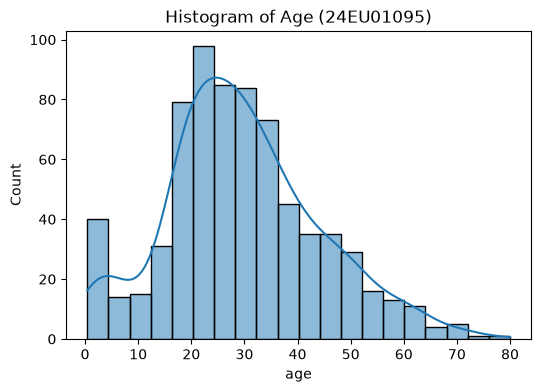

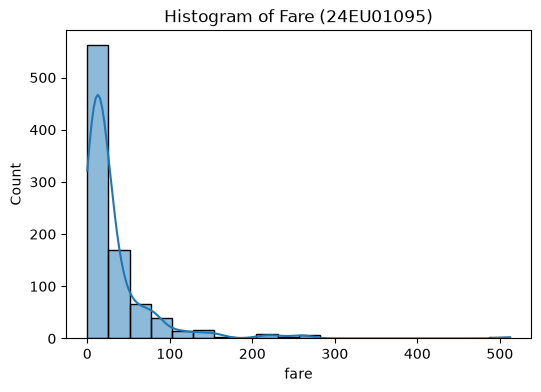

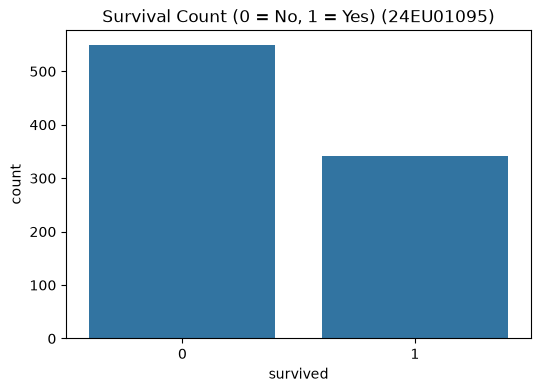

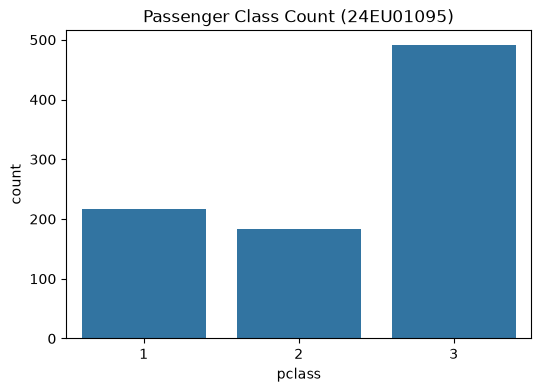

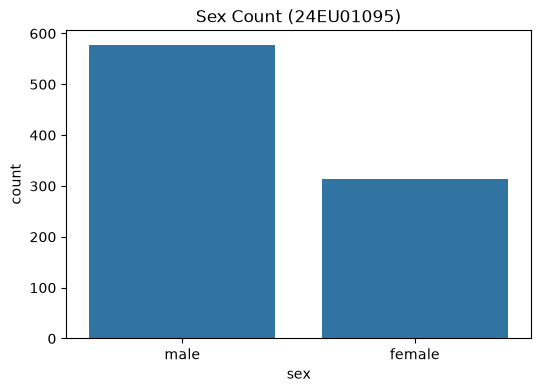

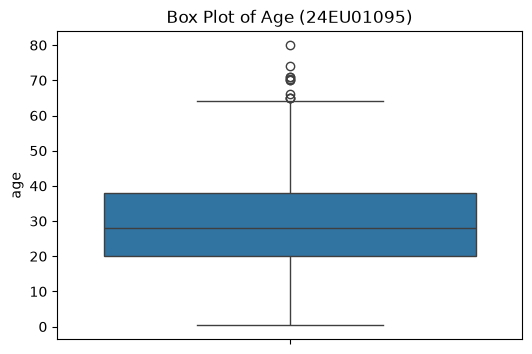

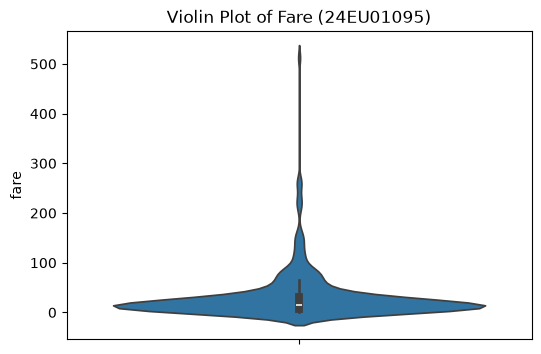

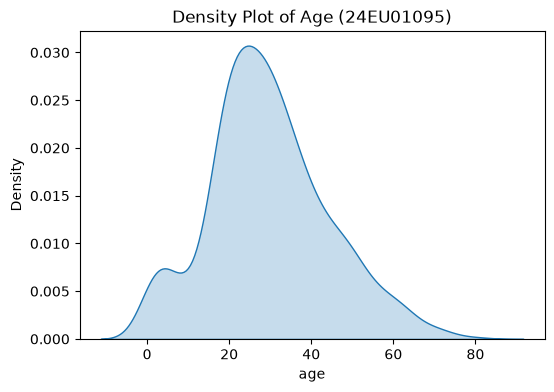

In [5]:
# ==========================================
# Univariate Visualizations
# ==========================================

# Histogram - Age distribution
plt.figure(figsize=(6,4))
sns.histplot(titanic["age"].dropna(), bins=20, kde=True)
plt.title("Histogram of Age (24EU01095)")
plt.show()

# Histogram - Fare distribution
plt.figure(figsize=(6,4))
sns.histplot(titanic["fare"], bins=20, kde=True)
plt.title("Histogram of Fare (24EU01095)")
plt.show()

# Count Plot - Survival counts
plt.figure(figsize=(6,4))
sns.countplot(x="survived", data=titanic)
plt.title("Survival Count (0 = No, 1 = Yes) (24EU01095)")
plt.show()

# Count Plot - Passenger class counts
plt.figure(figsize=(6,4))
sns.countplot(x="pclass", data=titanic)
plt.title("Passenger Class Count (24EU01095)")
plt.show()

# Count Plot - Sex counts
plt.figure(figsize=(6,4))
sns.countplot(x="sex", data=titanic)
plt.title("Sex Count (24EU01095)")
plt.show()

# Box Plot - Age
plt.figure(figsize=(6,4))
sns.boxplot(y="age", data=titanic)
plt.title("Box Plot of Age (24EU01095)")
plt.show()

# Violin Plot - Fare
plt.figure(figsize=(6,4))
sns.violinplot(y="fare", data=titanic)
plt.title("Violin Plot of Fare (24EU01095)")
plt.show()

# Density Plot - Age
plt.figure(figsize=(6,4))
sns.kdeplot(titanic["age"].dropna(), fill=True)
plt.title("Density Plot of Age (24EU01095)")
plt.show()


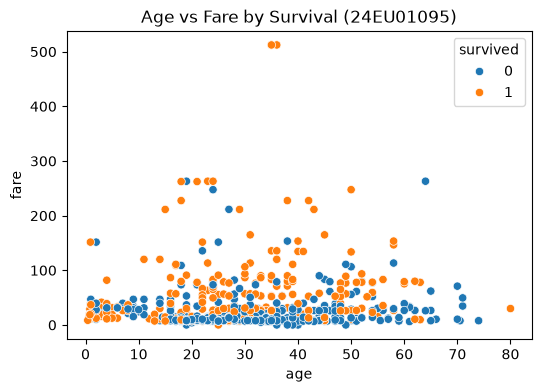

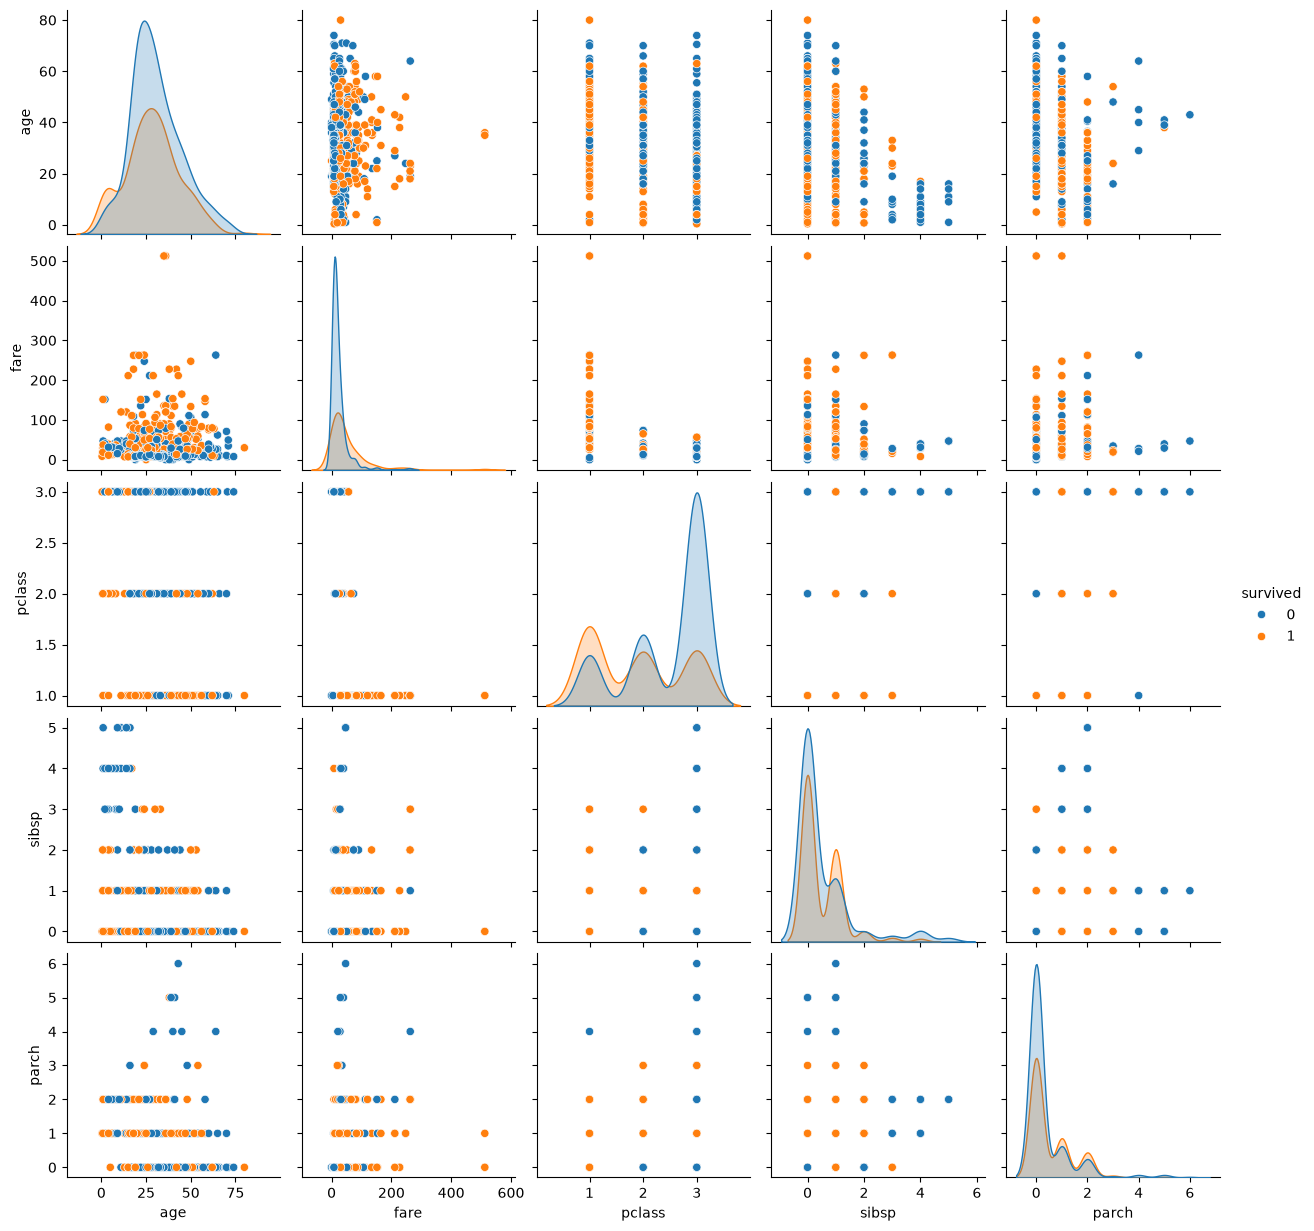

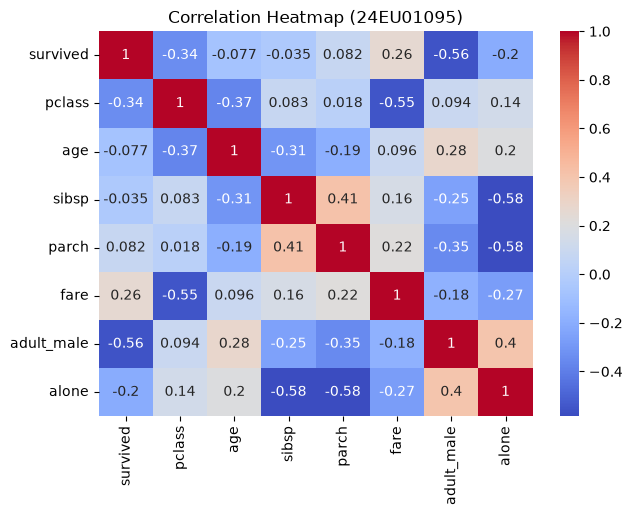

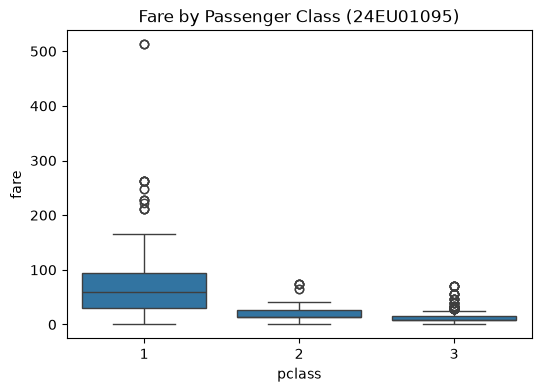

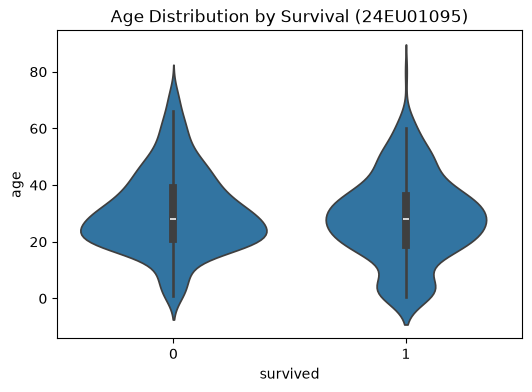

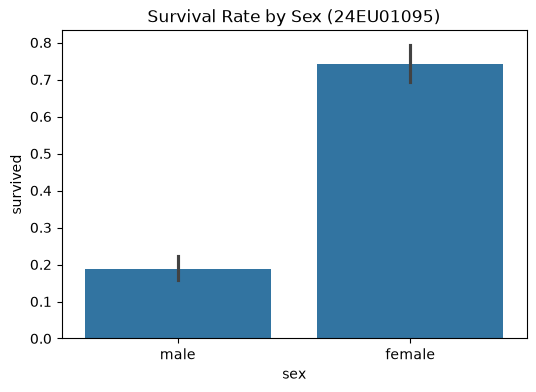

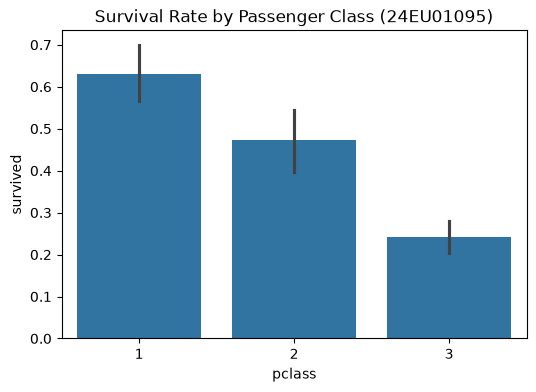

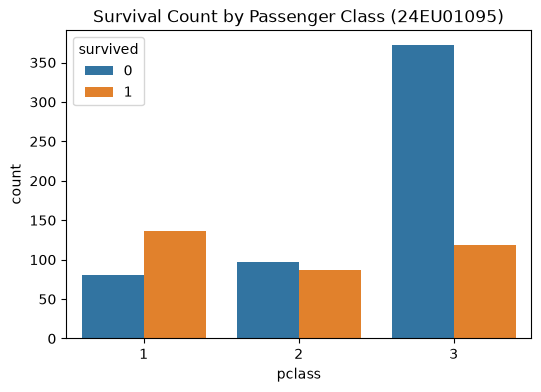

In [6]:
# ==========================================
# Multivariate Visualizations
# ==========================================

# Scatter Plot - Age vs Fare colored by Survived
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="fare", hue="survived", data=titanic)
plt.title("Age vs Fare by Survival (24EU01095)")
plt.show()

# Pair Plot - key numeric features colored by Survived
sns.pairplot(titanic[["survived", "age", "fare", "pclass", "sibsp", "parch"]].dropna(), hue="survived")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(titanic.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (24EU01095)")
plt.show()

# Box Plot - Fare by Passenger Class
plt.figure(figsize=(6,4))
sns.boxplot(x="pclass", y="fare", data=titanic)
plt.title("Fare by Passenger Class (24EU01095)")
plt.show()

# Violin Plot - Age by Survival
plt.figure(figsize=(6,4))
sns.violinplot(x="survived", y="age", data=titanic)
plt.title("Age Distribution by Survival (24EU01095)")
plt.show()

# Bar Plot - Survival rate by Sex
plt.figure(figsize=(6,4))
sns.barplot(x="sex", y="survived", data=titanic)
plt.title("Survival Rate by Sex (24EU01095)")
plt.show()

# Bar Plot - Survival rate by Passenger Class
plt.figure(figsize=(6,4))
sns.barplot(x="pclass", y="survived", data=titanic)
plt.title("Survival Rate by Passenger Class (24EU01095)")
plt.show()

# Count Plot - Survival split by Sex
plt.figure(figsize=(6,4))
sns.countplot(x="pclass", hue="survived", data=titanic)
plt.title("Survival Count by Passenger Class (24EU01095)")
plt.show()


In [7]:
# ==========================================
# Feature Correlation with Target (Survived)
# ==========================================

corr_with_target = titanic.corr(numeric_only=True)['survived'].sort_values(ascending=False)
print("===== Correlation of Numeric Features with Survival =====")
print(corr_with_target)

print("\n===== Summary of Key Observations =====")
print("1. Sex is the strongest categorical indicator: females had a much higher survival rate than males.")
print("2. Passenger class (pclass) shows a clear negative correlation with survival: 1st class passengers")
print("   survived at a notably higher rate than 3rd class passengers.")
print("3. Fare is positively correlated with survival, consistent with higher fares being linked to higher")
print("   class and better access to lifeboats.")
print("4. Age shows a weak negative correlation with survival; very young children had a somewhat higher")
print("   chance of survival, consistent with 'women and children first' evacuation priority.")
print("5. Family size features (sibsp, parch) show weak, non-linear relationships with survival, indicating")
print("   moderate family sizes fared slightly better than travelling completely alone or in very large groups.")
print("6. The 'age' and 'deck' columns contain a large proportion of missing values and would need imputation")
print("   or removal before being used in a predictive model.")


===== Correlation of Numeric Features with Survival =====
survived      1.000000
fare          0.257307
parch         0.081629
sibsp        -0.035322
age          -0.077221
alone        -0.203367
pclass       -0.338481
adult_male   -0.557080
Name: survived, dtype: float64

===== Summary of Key Observations =====
1. Sex is the strongest categorical indicator: females had a much higher survival rate than males.
2. Passenger class (pclass) shows a clear negative correlation with survival: 1st class passengers
   survived at a notably higher rate than 3rd class passengers.
3. Fare is positively correlated with survival, consistent with higher fares being linked to higher
   class and better access to lifeboats.
4. Age shows a weak negative correlation with survival; very young children had a somewhat higher
   chance of survival, consistent with 'women and children first' evacuation priority.
5. Family size features (sibsp, parch) show weak, non-linear relationships with survival, indicati